In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [ ]:
ddos_data = pd.read_csv('https://raw.githubusercontent.com/RayFarrington/MLTests/refs/heads/master/data/DDOS_Data.csv')
#https://www.kaggle.com/code/atulkumar011/ddos-attack-detection-classification-a03d6b
ddos_data.head()

,dt,switch,src,dst,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,...,pktrate,Pairflow,Protocol,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
0,11425,1,10.0.0.1,10.0.0.8,45304,48294064,100,716000000,1.010000e+11,3,...,451,0,UDP,3,143928631,3917,0,0.0,0.0,0
1,11605,1,10.0.0.1,10.0.0.8,126395,134737070,280,734000000,2.810000e+11,2,...,451,0,UDP,4,3842,3520,0,0.0,0.0,0
2,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,1,3795,1242,0,0.0,0.0,0
3,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,2,3688,1492,0,0.0,0.0,0
4,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,3,3413,3665,0,0.0,0.0,0


# EDA

In [ ]:
ddos_data.info(show_counts=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104345 entries, 0 to 104344
Data columns (total 23 columns):
 #   Column       Dtype  
---  ------       -----  
 0   dt           int64  
 1   switch       int64  
 2   src          object 
 3   dst          object 
 4   pktcount     int64  
 5   bytecount    int64  
 6   dur          int64  
 7   dur_nsec     int64  
 8   tot_dur      float64
 9   flows        int64  
 10  packetins    int64  
 11  pktperflow   int64  
 12  byteperflow  int64  
 13  pktrate      int64  
 14  Pairflow     int64  
 15  Protocol     object 
 16  port_no      int64  
 17  tx_bytes     int64  
 18  rx_bytes     int64  
 19  tx_kbps      int64  
 20  rx_kbps      float64
 21  tot_kbps     float64
 22  label        int64  
dtypes: float64(3), int64(17), object(3)
memory usage: 18.3+ MB


In [ ]:
ddos_data.isnull().sum()

,0
dt,0
switch,0
src,0
dst,0
pktcount,0
bytecount,0
dur,0
dur_nsec,0
tot_dur,0
flows,0


In [ ]:
#Here I am testing the hypothosis that total kbps is null at the same time the rx kbps is null. This makes sense because total = tx + rx
rx_null = ddos_data[ddos_data['rx_kbps'].isnull()].index
tot_test = ddos_data.loc[rx_null, 'tot_kbps'].isnull()
#if this is true then tot_kbps is null when rx_kbps is null, which is important to keep in mind when I deal with the missing values
tot_test.all()

np.True_

In [ ]:
ddos_data.describe()

,dt,switch,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,packetins,pktperflow,byteperflow,pktrate,Pairflow,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
count,104345.000000,104345.000000,104345.000000,1.043450e+05,104345.000000,1.043450e+05,1.043450e+05,104345.000000,104345.000000,104345.000000,1.043450e+05,104345.000000,104345.000000,104345.000000,1.043450e+05,1.043450e+05,104345.000000,103839.000000,103839.000000,104345.000000
mean,17927.514169,4.214260,52860.954746,3.818660e+07,321.497398,4.613880e+08,3.218865e+11,5.654234,5200.383468,6381.715291,4.716150e+06,212.210676,0.600987,2.331094,9.325264e+07,9.328039e+07,998.899756,1003.811420,2007.578742,0.390857
std,11977.642655,1.956327,52023.241460,4.877748e+07,283.518232,2.770019e+08,2.834029e+11,2.950036,5257.001450,7404.777808,7.560116e+06,246.855123,0.489698,1.084333,1.519380e+08,1.330004e+08,2423.471618,2054.887034,3144.437173,0.487945
min,2488.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,2.000000,4.000000,-130933.000000,-1.464426e+08,-4365.000000,0.000000,1.000000,2.527000e+03,8.560000e+02,0.000000,0.000000,0.000000,0.000000
25%,7098.000000,3.000000,808.000000,7.957600e+04,127.000000,2.340000e+08,1.270000e+11,3.000000,1943.000000,29.000000,2.842000e+03,0.000000,0.000000,1.000000,4.743000e+03,3.539000e+03,0.000000,0.000000,0.000000,0.000000
50%,11905.000000,4.000000,42828.000000,6.471930e+06,251.000000,4.180000e+08,2.520000e+11,5.000000,3024.000000,8305.000000,5.521680e+05,276.000000,1.000000,2.000000,4.219610e+06,1.338339e+07,0.000000,0.000000,4.000000,0.000000
75%,29952.000000,5.000000,94796.000000,7.620354e+07,412.000000,7.030000e+08,4.130000e+11,7.000000,7462.000000,10017.000000,9.728112e+06,333.000000,1.000000,3.000000,1.356398e+08,1.439277e+08,251.000000,557.000000,3838.000000,1.000000
max,42935.000000,10.000000,260006.000000,1.471280e+08,1881.000000,9.990000e+08,1.880000e+12,17.000000,25224.000000,19190.000000,1.495387e+07,639.000000,1.000000,5.000000,1.269982e+09,9.905962e+08,20580.000000,16577.000000,20580.000000,1.000000


'src', 'dst', and 'Protocol' are all objects, but I know that some of the other values are catagorical, such as the 'label' which is 1 or 0. Based on my knowlage of the data and the number of unique values, that 'switch', 'Pairflow', and 'port_no' should be catagorical as well.

In [ ]:
ddos_data.nunique()

,0
dt,859
switch,10
src,19
dst,18
pktcount,9045
bytecount,9271
dur,840
dur_nsec,1000
tot_dur,4183
flows,15


The data is very skewed. This is normal for the data set as most network data will have low data transfer, but a ddos will have as much as possible.

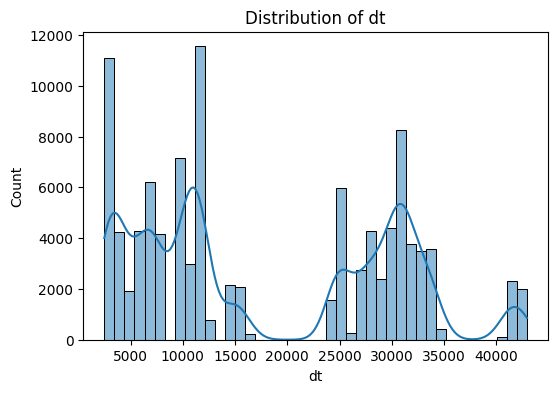

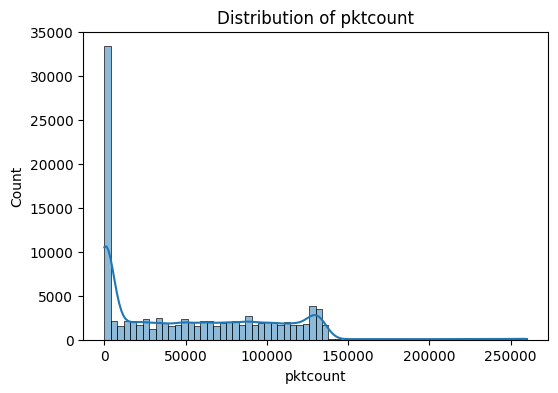

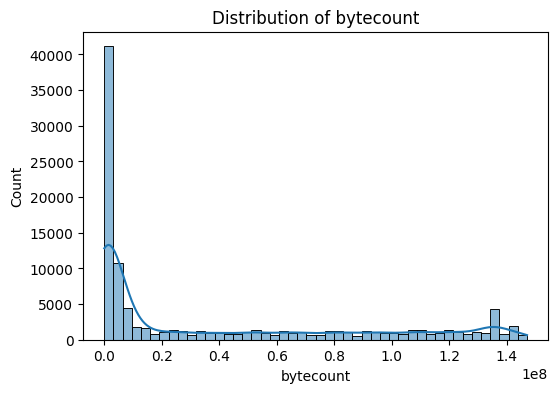

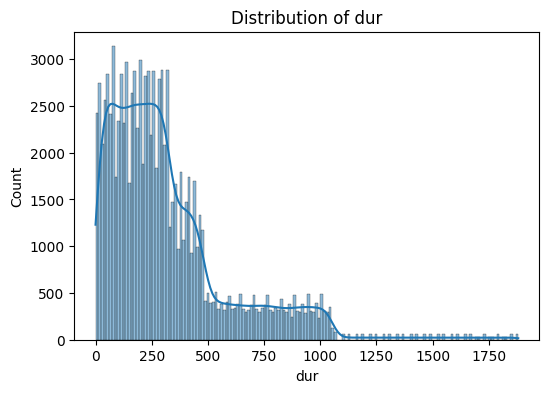

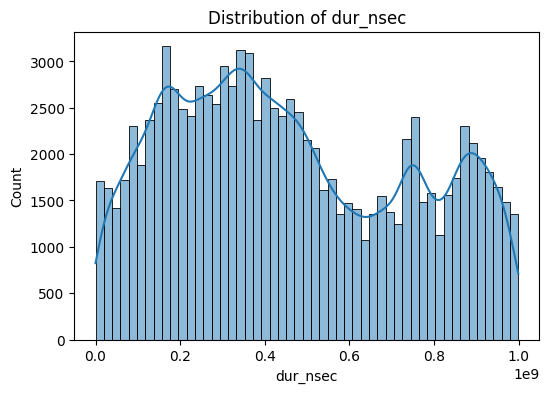

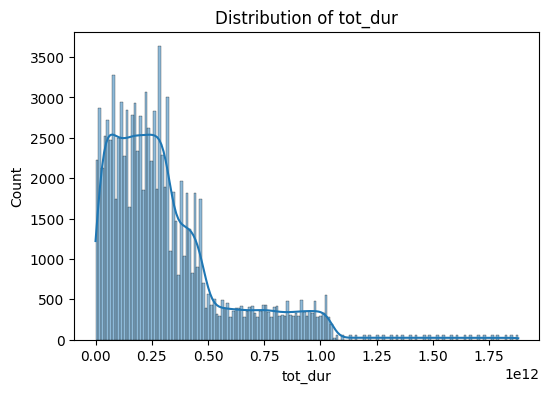

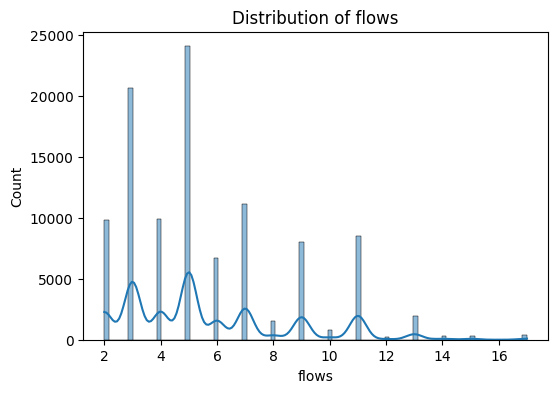

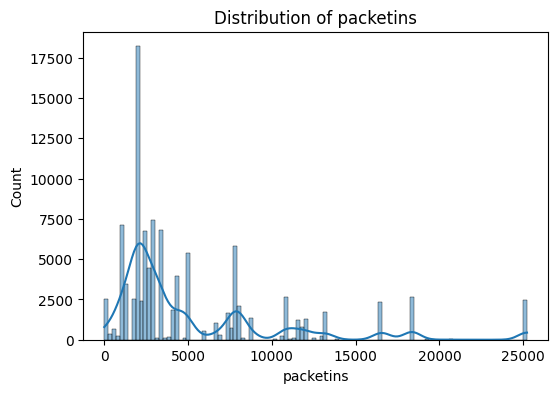

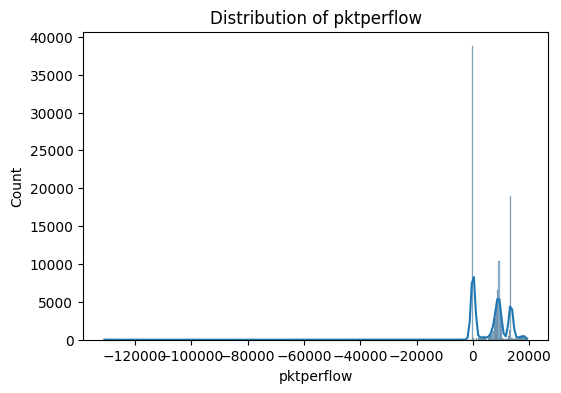

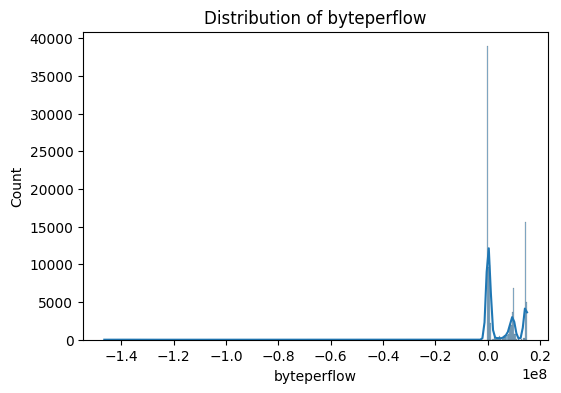

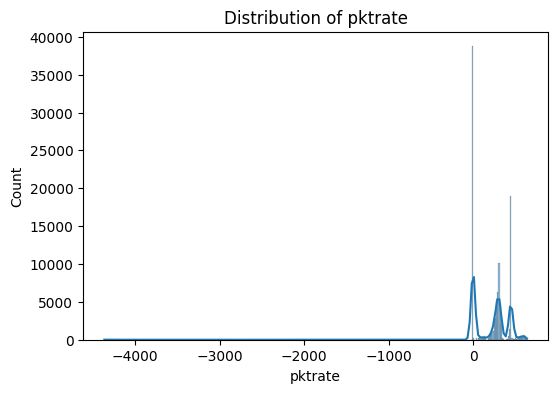

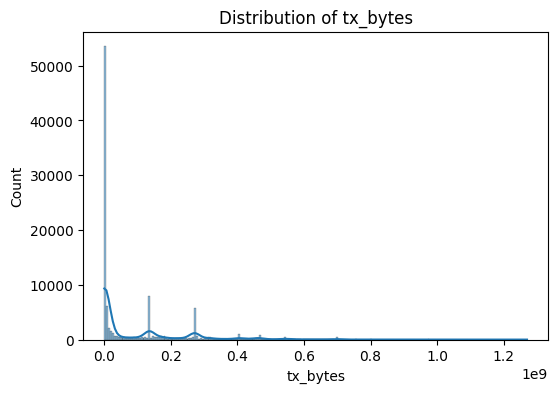

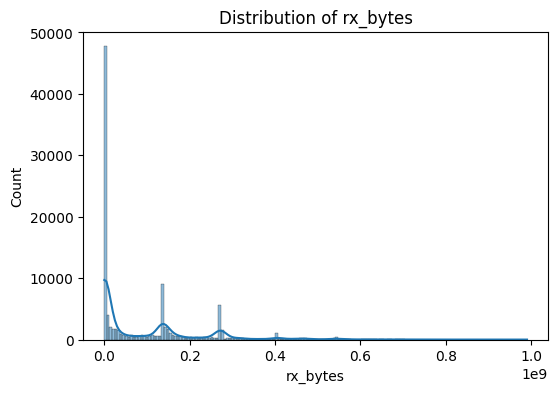

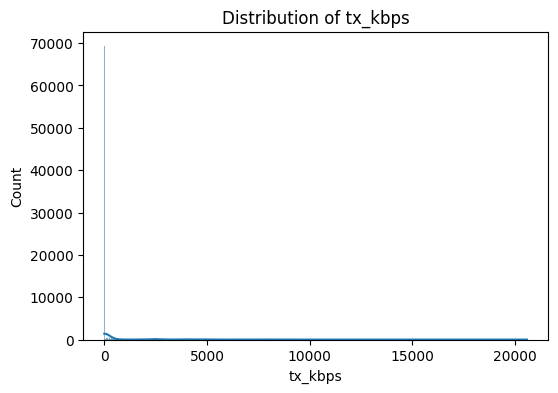

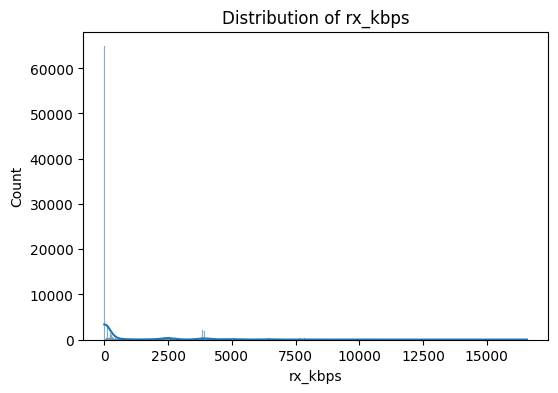

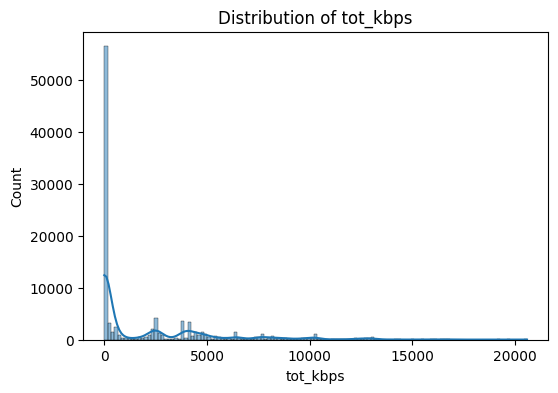

In [ ]:
numerical_features = ddos_data.select_dtypes(include=['int64', 'float64']).drop(columns=['switch', 'Pairflow', 'port_no', 'label']).columns
for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(ddos_data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

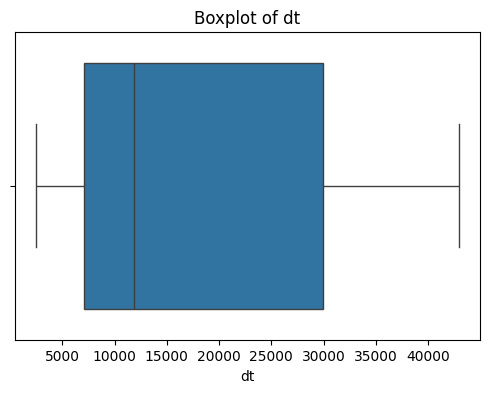

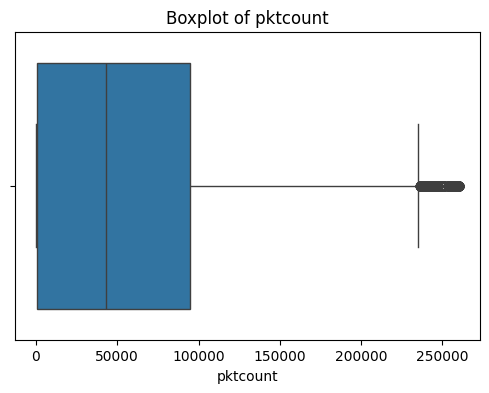

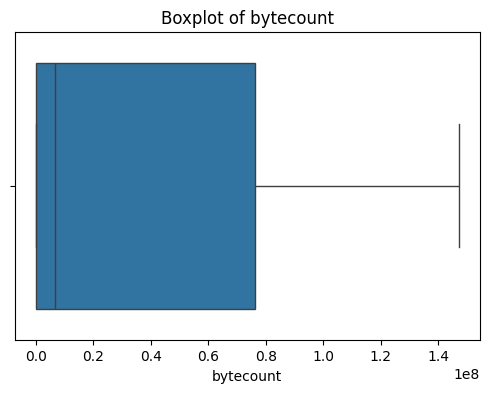

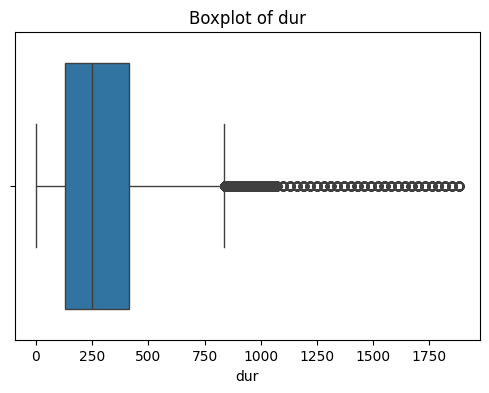

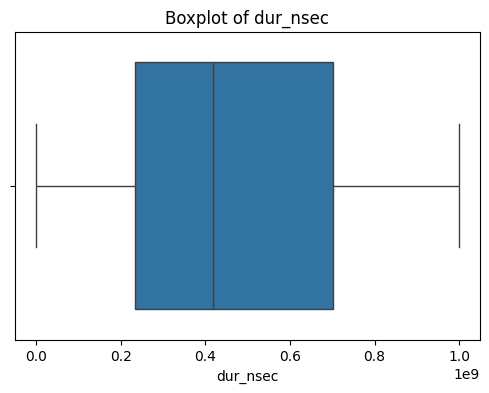

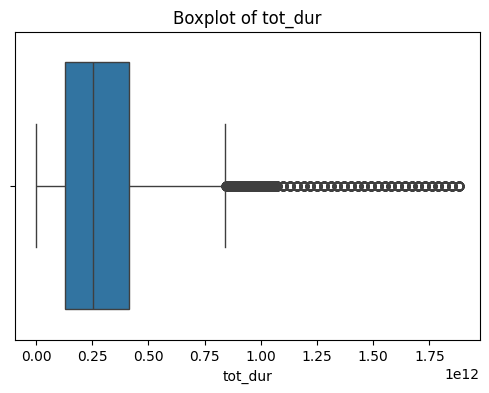

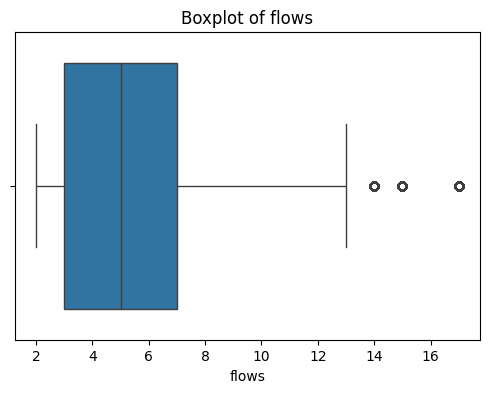

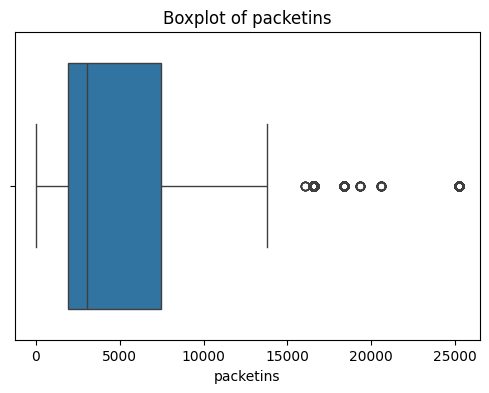

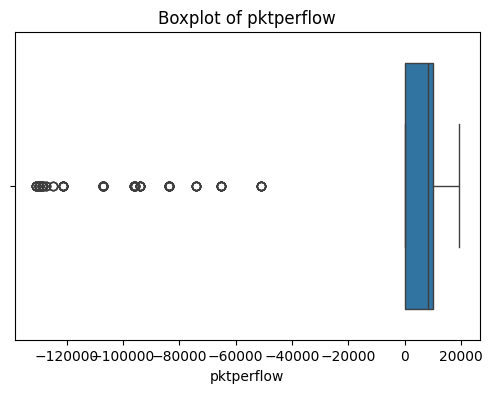

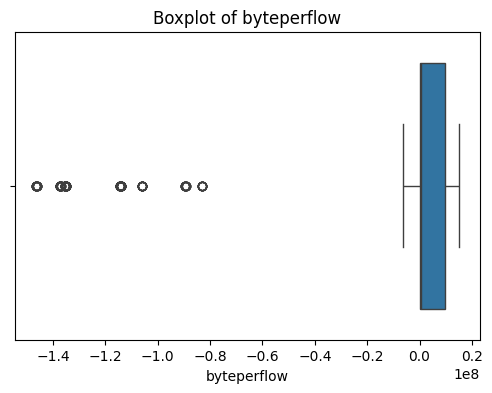

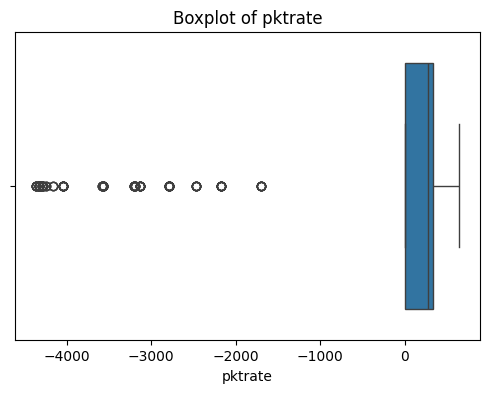

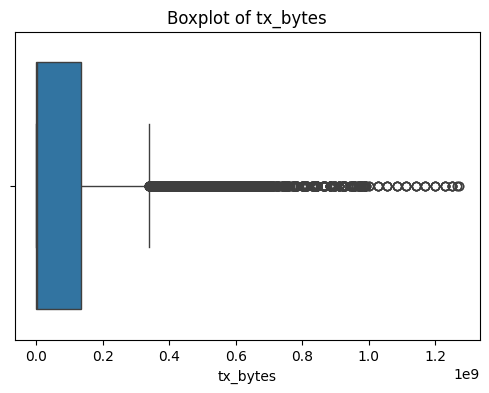

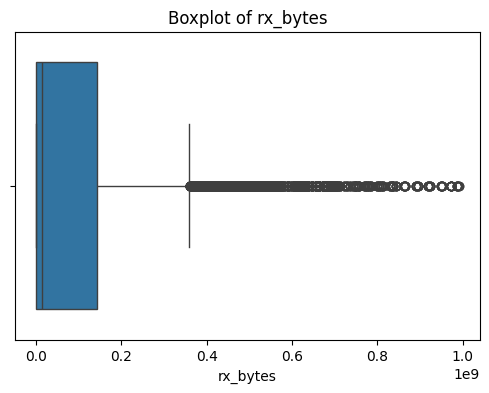

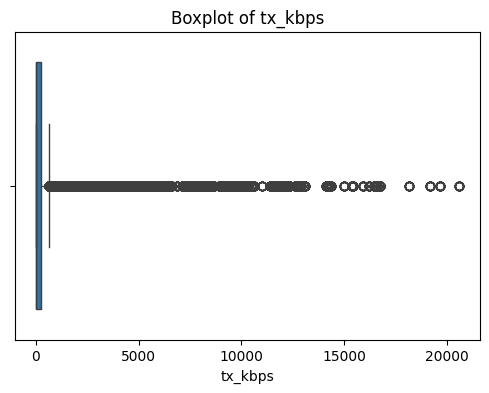

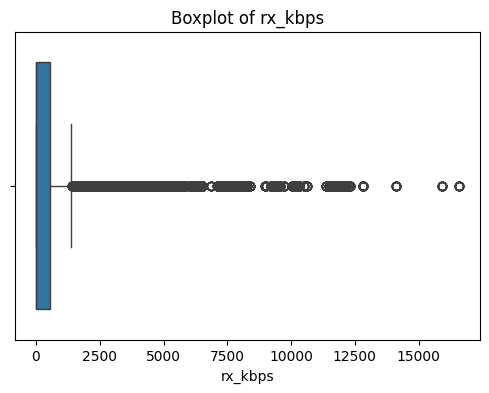

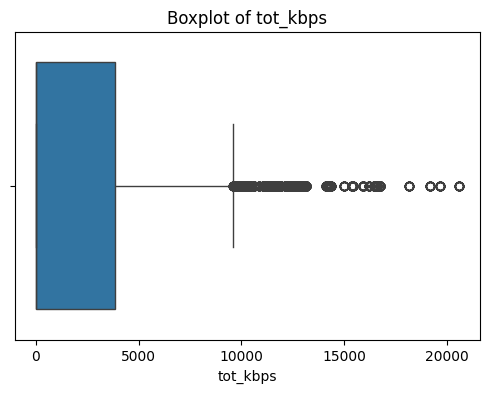

In [ ]:
for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=ddos_data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

There is an acceptable ratio of normal and ddos data

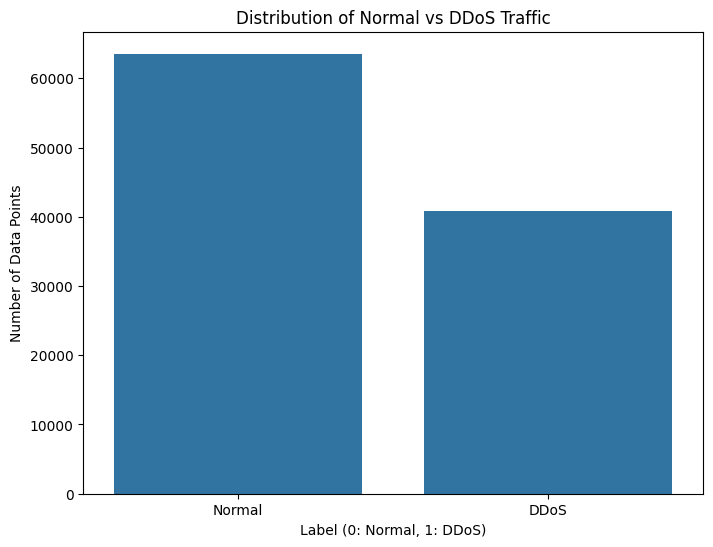

In [ ]:
label_counts = ddos_data['label'].value_counts()


plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Distribution of Normal vs DDoS Traffic')
plt.xlabel('Label (0: Normal, 1: DDoS)')
plt.ylabel('Number of Data Points')
plt.xticks(ticks=[0, 1], labels=['Normal', 'DDoS'])
plt.show()

Looking at the correlation, there are 4 pairs that have a correlation greater than 0.8. 'tot_dur' and 'dur' seem to be copies of each other so I will delete 'tot_dur'.

Then 'byteperflow', 'pktperflow', and 'pktrate' are related. Which makes sense. Because we have bytes, packets, and flows, I am just going to keep pktrate.

In [ ]:
correlation_matrix = ddos_data[numerical_features].corr()
print("Features with correlation greater than 0.8:")
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            print(f"Feature Pair: ({correlation_matrix.columns[i]}, {correlation_matrix.columns[j]}) => Correlation: {correlation_matrix.iloc[i, j]:.2f}")


Features with correlation greater than 0.8:
Feature Pair: (tot_dur, dur) => Correlation: 1.00
Feature Pair: (byteperflow, pktperflow) => Correlation: 0.81
Feature Pair: (pktrate, pktperflow) => Correlation: 1.00
Feature Pair: (pktrate, byteperflow) => Correlation: 0.81


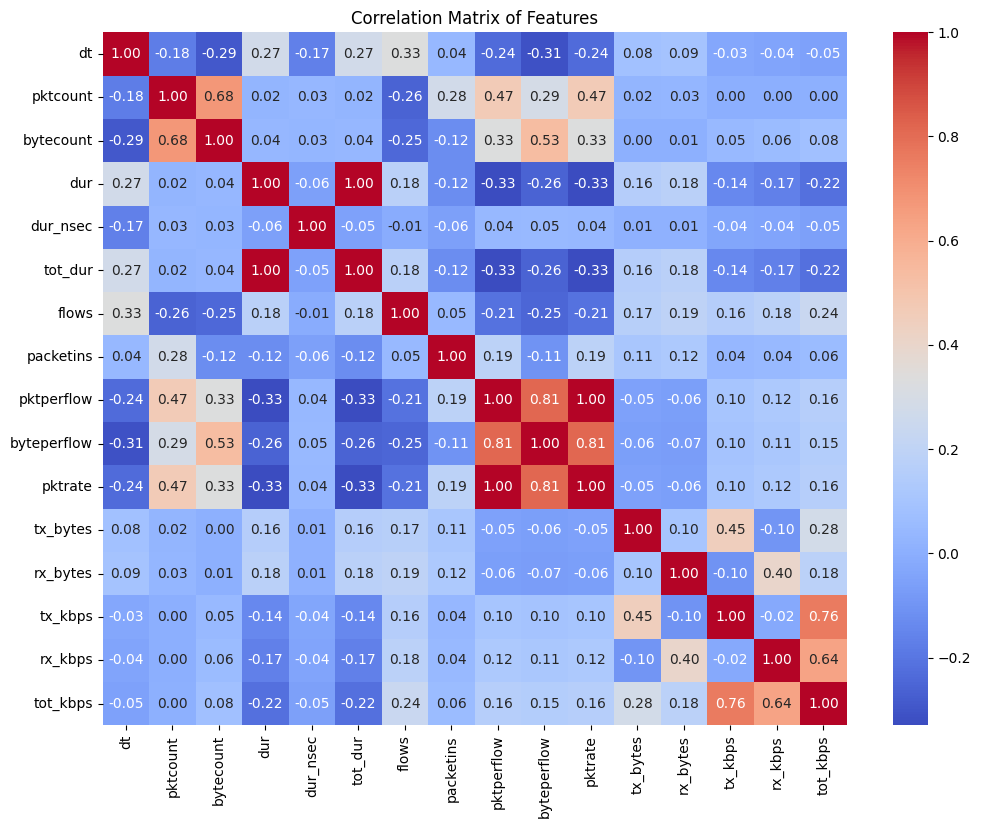

In [ ]:
plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

# Data Cleaning

Deleting these three features based on the EDA

In [ ]:
ddos_data_clean = ddos_data.copy()
ddos_data_clean.drop(columns=['byteperflow', 'pktperflow', 'tot_dur'], inplace=True)
ddos_data_clean.head()

,dt,switch,src,dst,pktcount,bytecount,dur,dur_nsec,flows,packetins,pktrate,Pairflow,Protocol,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
0,11425,1,10.0.0.1,10.0.0.8,45304,48294064,100,716000000,3,1943,451,0,UDP,3,143928631,3917,0,0.0,0.0,0
1,11605,1,10.0.0.1,10.0.0.8,126395,134737070,280,734000000,2,1943,451,0,UDP,4,3842,3520,0,0.0,0.0,0
2,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,3,1943,451,0,UDP,1,3795,1242,0,0.0,0.0,0
3,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,3,1943,451,0,UDP,2,3688,1492,0,0.0,0.0,0
4,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,3,1943,451,0,UDP,3,3413,3665,0,0.0,0.0,0


I am adding the median value to rx_kbps, but I'm adding the median rx to the tx to get the total to keep tot = tx + rx as true

In [ ]:
median_val = ddos_data_clean['rx_kbps'].median()
ddos_data_clean.fillna({'rx_kbps': median_val}, inplace=True)

tot_index = ddos_data_clean[ddos_data_clean['tot_kbps'].isnull()].index
ddos_data_clean.loc[tot_index, 'tot_kbps'] = ddos_data_clean.loc[tot_index, 'tx_kbps'] + ddos_data_clean.loc[tot_index, 'rx_kbps']

ddos_data_clean.isnull().sum()

,0
dt,0
switch,0
src,0
dst,0
pktcount,0
bytecount,0
dur,0
dur_nsec,0
flows,0
packetins,0


# Feature Engineering

I am adding two new features based on what I know about the data. First is bytes per packet, which is important to distinguish network data where a lot of data is sent at once, like a download, vs an attack where a lot of data is sent in a lot of packets.

And second is the ratio of transmission bytes and receiving bytes, which is useful because it might not be an attack if the server is matching the high data.

In [ ]:
ddos_data_clean['bytes_per_packet'] = ddos_data_clean['bytecount'] / (ddos_data_clean['pktcount'] + 1e-6)

ddos_data_clean['tx_rx_ratio_bytes'] = ddos_data_clean['tx_bytes'] / (ddos_data_clean['rx_bytes'] + 1e-6)


I use logarithmic scaling to try to keep the feature of huge data spikes. Robust scaler scales to median = 0. This is to keep the features of an attack

In [ ]:
from sklearn.preprocessing import RobustScaler

ddos_data_clean['pktrate'] = ddos_data_clean['pktrate'].clip(lower=0)

numerical_features = ddos_data_clean.select_dtypes(include=['int64', 'float64']).drop(columns=['switch', 'Pairflow', 'port_no', 'label']).columns

for col in numerical_features:
  ddos_data_clean[col] = np.log1p(ddos_data_clean[col])

scaler = RobustScaler()
ddos_data_clean[numerical_features] = scaler.fit_transform(ddos_data_clean[numerical_features])
ddos_data_clean[numerical_features].describe()


,dt,pktcount,bytecount,dur,dur_nsec,flows,packetins,pktrate,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,bytes_per_packet,tx_rx_ratio_bytes
count,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,1.043450e+05,104345.000000
mean,0.078185,-0.268578,-0.104216,-0.158596,-0.176599,0.017210,0.053168,-0.330822,-0.140026,-0.219450,0.450004,0.442580,0.270034,4.235333e-01,0.814829
std,0.581877,0.533504,0.492515,0.928648,0.959654,0.613093,0.840351,0.471134,0.470229,0.483200,0.616169,0.559272,0.474241,5.580558e-01,2.137325
min,-1.087163,-2.238803,-2.284671,-4.720290,-18.045769,-1.000000,-4.761509,-0.967799,-0.723142,-0.909841,0.000000,0.000000,-0.195013,-1.951437e+00,-0.504185
25%,-0.359170,-0.833213,-0.640767,-0.578273,-0.527401,-0.584963,-0.328695,-0.967799,-0.661797,-0.776189,0.000000,0.000000,-0.195013,-5.004106e-09,-0.451684
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
75%,0.640830,0.166787,0.359233,0.421727,0.472599,0.415037,0.671305,0.032201,0.338203,0.223811,1.000000,1.000000,0.804987,1.000000e+00,0.548316
max,0.890943,0.378591,0.455074,1.716435,0.792041,1.584963,1.576650,0.144111,0.556192,0.405570,1.796229,1.548864,1.008448,1.079522e+00,8.074342


Finaly I used one hot encoding on the catagorical features

In [ ]:
cat_features = ['src', 'dst', 'Protocol', 'switch', 'Pairflow', 'port_no']
ohe = OneHotEncoder()

encoded_data = pd.DataFrame(
    ohe.fit_transform(ddos_data_clean[cat_features]).toarray(),
    columns=ohe.get_feature_names_out(cat_features)
    )

ddos_data_encoded = pd.concat([ddos_data_clean.drop(columns=cat_features), encoded_data], axis=1)

ddos_data_encoded.head()

,dt,pktcount,bytecount,dur,dur_nsec,flows,packetins,pktrate,tx_bytes,rx_bytes,...,switch_8,switch_9,switch_10,Pairflow_0,Pairflow_1,port_no_1,port_no_2,port_no_3,port_no_4,port_no_5
0,-0.028584,0.011798,0.292789,-0.780515,0.489256,-0.584963,-0.328695,0.084263,0.343984,-0.766629,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.017726,0.227178,0.442258,0.092986,0.511827,-1.000000,-0.328695,0.084263,-0.682324,-0.776696,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.028584,0.156664,0.393323,-0.193035,0.524128,-0.584963,-0.328695,0.084263,-0.683523,-0.874804,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,-0.028584,0.156664,0.393323,-0.193035,0.524128,-0.584963,-0.328695,0.084263,-0.686310,-0.857536,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.028584,0.156664,0.393323,-0.193035,0.524128,-0.584963,-0.328695,0.084263,-0.693860,-0.772893,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


# Training the Model

Between Logistical Regression, ANN, and CNN, I decided that a logistical regression model is best for this dataset. CNN is best suited for image data, but it is technically able to be used, and I found some studies that experimented with using CNN to detect DDoS attacks on IoT devices.


But, in general, a logistical regression model has the advantage of being more interpretable and having better performance once it is trained. These are important because knowing what features best indicate an attack can inform policy beyond the implimentation of the model. And performance is very important when implimenting the model becuase a DDoS attack will affect the performance of the targeted machine. The model needs to act quickly and not take up too much processing power when an attack does come.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

X = ddos_data_encoded.drop('label', axis=1)
y = ddos_data_encoded['label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
#important functions for the training

#this function evaluates the model and prints a confusion matrix and a classification report
def evaluate_model(model, X_test, y_test):
  y_pred = model.predict(X_test)
  conf_matrix = confusion_matrix(y_test, y_pred)
  print("Confusion Matrix:")
  plt.figure(figsize=(8, 6))
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
              xticklabels=['Predicted Normal', 'Predicted DDoS'],
              yticklabels=['Actual Normal', 'Actual DDoS'])
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.show()

  print("\nClassification Report:")
  print(classification_report(y_test, y_pred))
  print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

#this funtion plots the ROC curves of a set of models
def plot_roc_curves(models, X_test, y_test):
  plt.figure(figsize=(10, 8))
  for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

  plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic (ROC) Curve')
  plt.legend(loc='lower right')
  plt.grid(True)
  plt.show()

#this function creates a bar graph of the models accuracy
def plot_accuracy_scores(models, X_test, y_test):
    accuracy_scores = []
    model_names = []
    for name, model in models.items():
        score = model.score(X_test, y_test)
        accuracy_scores.append(score)
        model_names.append(name)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=model_names, y=accuracy_scores)
    plt.ylim(min(accuracy_scores) * 0.9, max(accuracy_scores) * 1.05)
    plt.title('Accuracy Scores of Different Models')
    plt.ylabel('Accuracy Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

###Model v.1

This model just uses the default values for skikits Logistical Regression model

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Confusion Matrix:


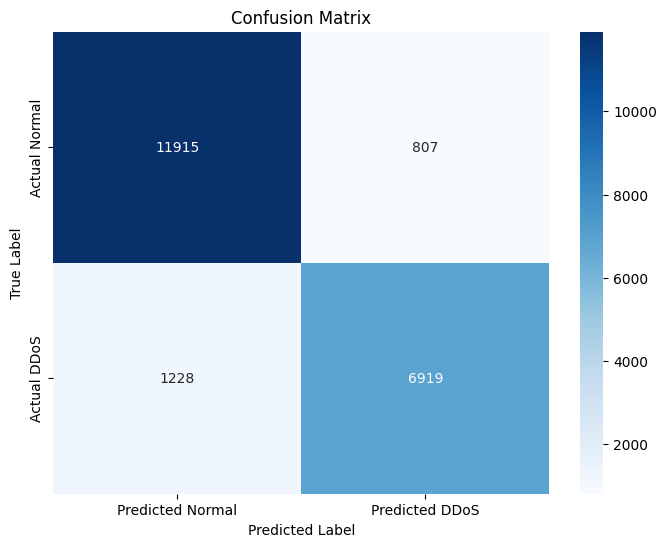


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92     12722
           1       0.90      0.85      0.87      8147

    accuracy                           0.90     20869
   macro avg       0.90      0.89      0.90     20869
weighted avg       0.90      0.90      0.90     20869

Accuracy Score: 0.9025


In [ ]:

model1 = LogisticRegression()

model1.fit(X_train, y_train)

evaluate_model(model1, X_val, y_val)

###Model v.2

Doubling the max iterations

Confusion Matrix:


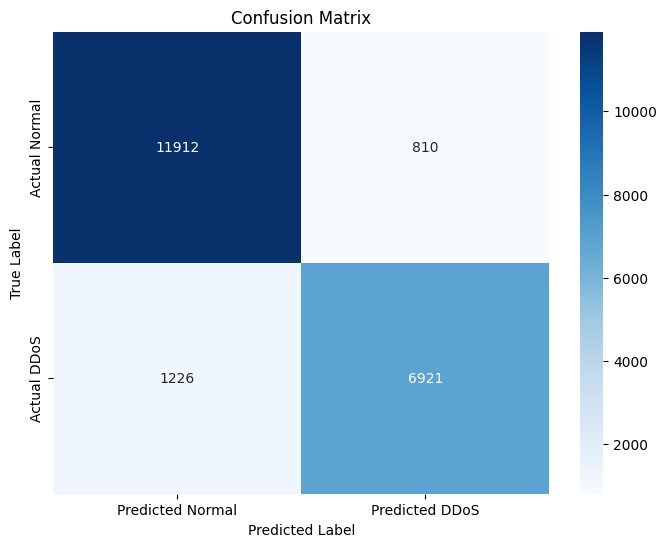


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92     12722
           1       0.90      0.85      0.87      8147

    accuracy                           0.90     20869
   macro avg       0.90      0.89      0.90     20869
weighted avg       0.90      0.90      0.90     20869

Accuracy Score: 0.9024


In [ ]:
model2 = LogisticRegression(max_iter=200)

model2.fit(X_train, y_train)

evaluate_model(model2, X_val, y_val)

###Model v.3
For this model, I choose the liblinear solver. This solver is best suited for small datasets and can only be used for binary classification, which fits this dataset

Confusion Matrix:


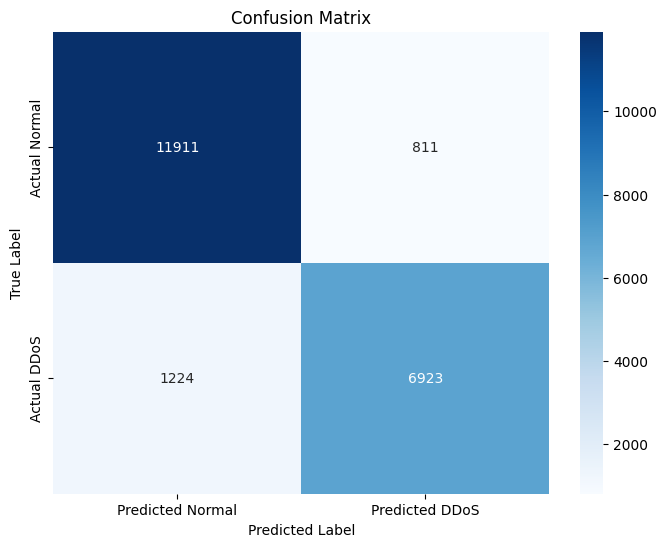


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92     12722
           1       0.90      0.85      0.87      8147

    accuracy                           0.90     20869
   macro avg       0.90      0.89      0.90     20869
weighted avg       0.90      0.90      0.90     20869

Accuracy Score: 0.9025


In [ ]:
model3 = LogisticRegression(solver = 'liblinear')

model3.fit(X_train, y_train)

evaluate_model(model3, X_val, y_val)

###Model v.4

For this model I modified the C value. This is the inverse regularization strength. Meaning that low C values means stronger regularization.

Confusion Matrix:


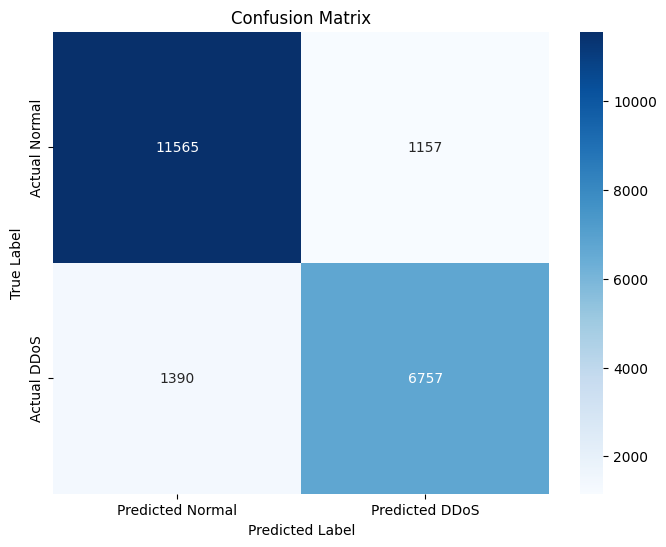


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     12722
           1       0.85      0.83      0.84      8147

    accuracy                           0.88     20869
   macro avg       0.87      0.87      0.87     20869
weighted avg       0.88      0.88      0.88     20869

Accuracy Score: 0.8780


In [ ]:
model4 = LogisticRegression(solver = 'liblinear', C=0.01)

model4.fit(X_train, y_train)

evaluate_model(model4, X_val, y_val)

###Model v.5

For this model I increased the C value, which means weaker regularization.

Confusion Matrix:


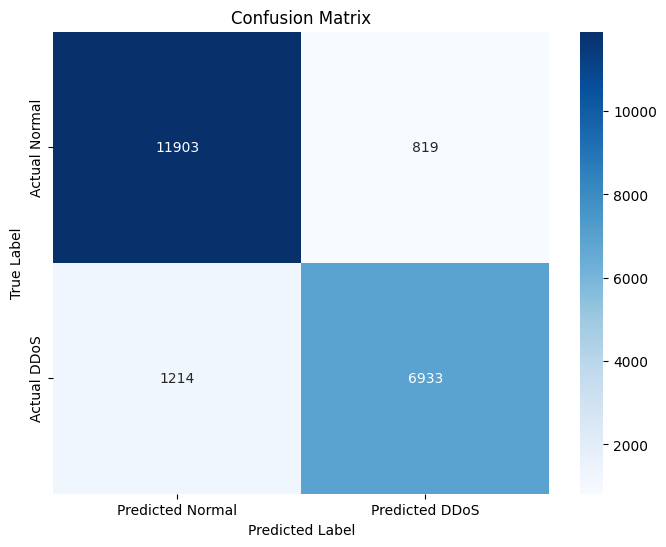


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92     12722
           1       0.89      0.85      0.87      8147

    accuracy                           0.90     20869
   macro avg       0.90      0.89      0.90     20869
weighted avg       0.90      0.90      0.90     20869

Accuracy Score: 0.9026


In [ ]:
model5 = LogisticRegression(solver = 'liblinear', C=10)

model5.fit(X_train, y_train)

evaluate_model(model5, X_val, y_val)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Define the ANN model
model_ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.25),
    Dense(64, activation='relu'),
    Dropout(0.25),
    Dense(32, activation='relu'),
    Dropout(0.25),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history_ann = model_ann.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val), verbose=1)

# Evaluate the ANN model
print("\n--- ANN Model Evaluation ---")
evaluate_model(model_ann, X_val, y_val)

###Training results

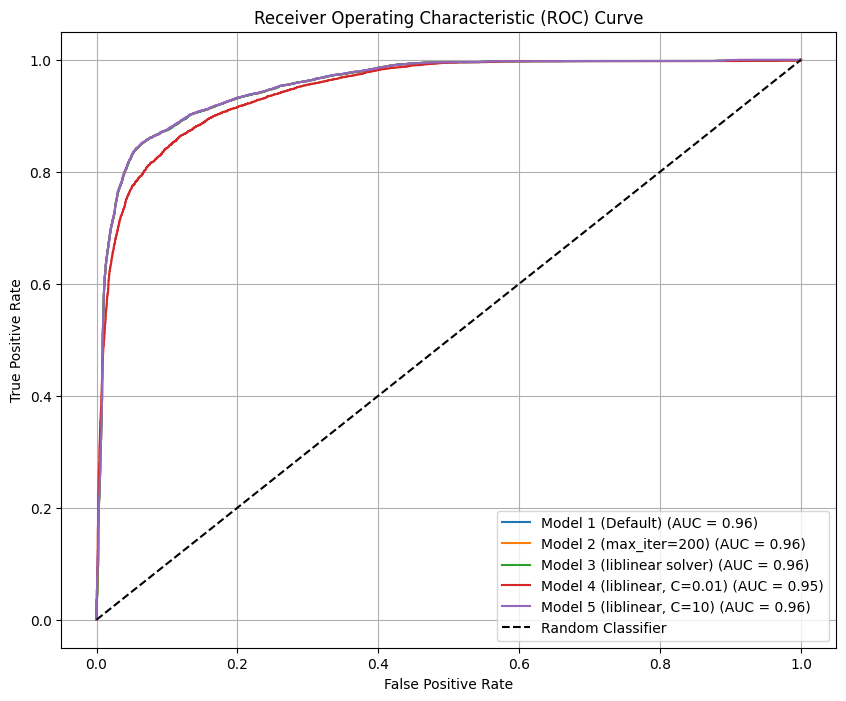

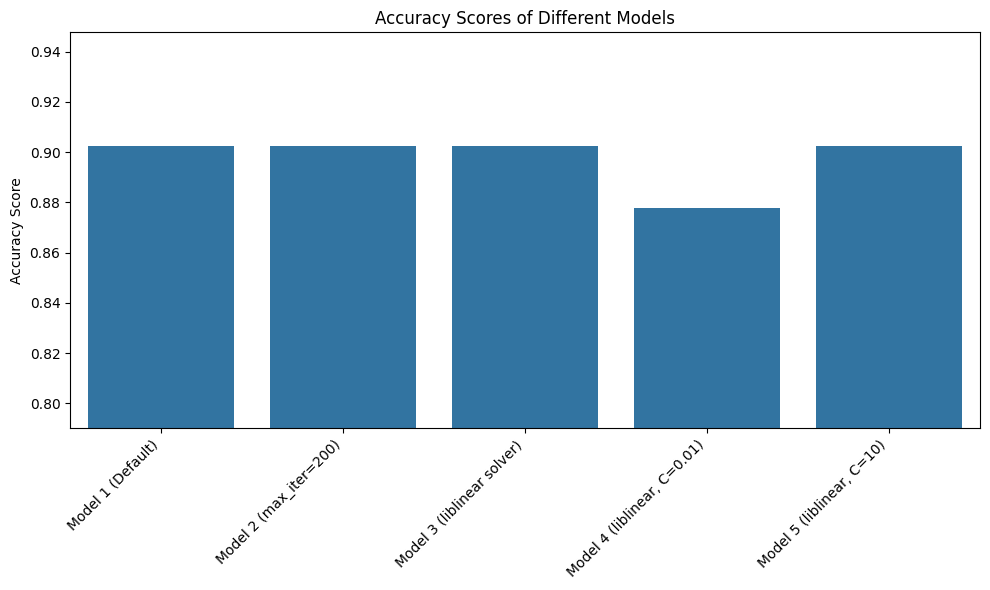

In [ ]:
models = {
    'Model 1 (Default)': model1,
    'Model 2 (max_iter=200)': model2,
    'Model 3 (liblinear solver)': model3,
    'Model 4 (liblinear, C=0.01)': model4,
    'Model 5 (liblinear, C=10)': model5
}

plot_roc_curves(models, X_val, y_val)

plot_accuracy_scores(models, X_val, y_val)

###Final reflection

The liblinear is the best solver for the model, beyond the metrics graphed above, liblinear was much faster to train while maintaining the same accuracy as lbfgs. But changing the regularization seems to have a limited effect. This could mean that the 90% accuracy is either the limit for logistical regurlization, or the limit for this amount of data. Exploring more models could produce better results.

Outside of this project, there are signs of great results with KNN and Random Forest. These weren't part of the approved models, but I think that shows the power of "simpler" models in machine learning.

#Final Report

###Final Analysis

The best performing model that has the best chance of not overfitting is model 3. Which is the model that uses the Liblinear solver. Most of the models performed similarly in accuracy except for the stronger regulization. I believe the lower regulization is not the best model because it increases the chance of overfitting at not a significant accuracy gain.
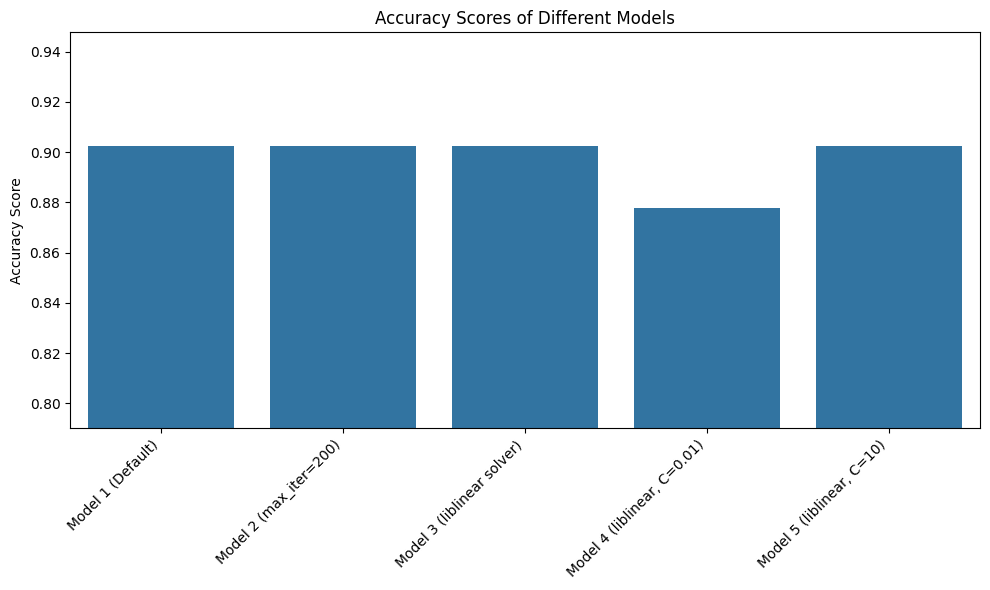

This model is not perfect, and other models can produce better results, as stated above. But this model needs to be able to use as little processing power as possible to handle scenarios where the host machine for the model is potentially being DDoSed.

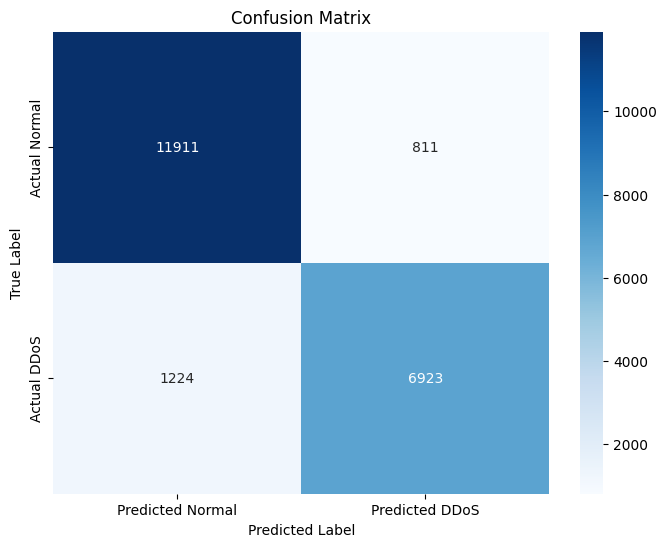

A future improvement for the model would be to change how sensitive the model is to an attack. The confusion matrix shows the the model is more likly to error on the side of signaling that a data point is not an attack when it actually is. Depending on where the model is deployed this may be preferable to prevent blocking real data. But if security is more important, it may be better to error on the side of caution.

###Deployment Plan

This model would act as a filter for a network server. Network data would be fed to the model which would signal if the model detects that a client's network flow is potentially part of a DDoS attack. This information would signal the system to take action such blocking the attacking IP address or increasing bandwidth.

#####Deployment steps:

1. Data collection -  Data is collected from tools like Netflow that capture network flow data

2. Preprocess data - repeat the steps to process the data so it matches the training data

3. Model prediction - use to model to predict a label

4. Data logging - Log data about model use and data to monitor the model's performance and audits.

5. System intergration - the model prediction is intergrated with the existing network security to take action based on the prediction.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression


def ddos_model_func(raw_data):
    data = raw_data.copy()

    # Step 1: Data preprocessing should copy the process from when the model was trained
    cols_to_drop_for_new_data = ['byteperflow', 'pktperflow', 'tot_dur']
    data.drop(columns=[col for col in cols_to_drop_for_new_data if col in data.columns], inplace=True, errors='ignore')

    #Fill missing values
    data.fillna({'rx_kbps': median_val}, inplace=True)

    tot_index_for_new_data = data[data['tot_kbps'].isnull()].index
    if not tot_index_for_new_data.empty:
        data.loc[tot_index_for_new_data, 'tot_kbps'] = \
            data.loc[tot_index_for_new_data, 'tx_kbps'] + \
            data.loc[tot_index_for_new_data, 'rx_kbps']

    #Feature Engineering
    data['bytes_per_packet'] = data['bytecount'] / (data['pktcount'] + 1e-6)
    data['tx_rx_ratio_bytes'] = data['tx_bytes'] / (data['rx_bytes'] + 1e-6)

    data['pktrate'] = data['pktrate'].clip(lower=0)

    #Apply log transform to numerical features
    for col in numerical_features:
        if col in data.columns:
            data[col] = np.log1p(data[col])

    data[numerical_features] = scaler.transform(data[numerical_features])

    #Apply OneHotEncoder to categorical features
    if 'label' in data.columns:
        processed_new_data_for_encoding = data.drop(columns=['label'])
    else:
        processed_new_data_for_encoding = data.copy()

    categorical_data_for_ohe = processed_new_data_for_encoding[cat_features]
    encoded_new_cat_data = pd.DataFrame(
        ohe.transform(categorical_data_for_ohe).toarray(),
        columns=ohe.get_feature_names_out(cat_features),
        index=data.index
    )

    final_data = data.drop(columns=cat_features, errors='ignore')
    final_data.drop(columns=['label'], errors='ignore', inplace=True)

    final_data = pd.concat([final_data, encoded_new_cat_data], axis=1)

    missing_cols = set(X_train.columns) - set(final_data.columns)
    for c in missing_cols:
        final_data[c] = 0
    extra_cols = set(final_data.columns) - set(X_train.columns)
    final_data.drop(columns=list(extra_cols), inplace=True, errors='ignore')

    final_data = final_data[X_train.columns]

    predictions = model3.predict(final_data)

    return predictions



In [ ]:
#For this example we get the first 3 normal and attack examples
raw_data = pd.concat([ddos_data[ddos_data['label'] == 0].head(3), ddos_data[ddos_data['label'] == 1].head(3)]).copy()

predictions = ddos_model_func(raw_data)

print("--- Mock Deployment Results for Model 3 ---")
print("-------------------------------------------")
for i, (pred, original_label) in enumerate(zip(predictions, raw_data['label'])):
    predicted_label = "DDoS Attack (1)" if pred == 1 else "Normal Traffic (0)"
    actual_label = "DDoS Attack (1)" if original_label == 1 else "Normal Traffic (0)"
    print(f"Sample {i+1}:")
    print(f"  Predicted: {predicted_label}")
    print(f"  Actual Label: {actual_label}")
    print("-" * 20)

--- Mock Deployment Results for Model 3 ---
-------------------------------------------
Sample 1:
  Predicted: Normal Traffic (0)
  Actual Label: Normal Traffic (0)
--------------------
Sample 2:
  Predicted: Normal Traffic (0)
  Actual Label: Normal Traffic (0)
--------------------
Sample 3:
  Predicted: Normal Traffic (0)
  Actual Label: Normal Traffic (0)
--------------------
Sample 4:
  Predicted: DDoS Attack (1)
  Actual Label: DDoS Attack (1)
--------------------
Sample 5:
  Predicted: DDoS Attack (1)
  Actual Label: DDoS Attack (1)
--------------------
Sample 6:
  Predicted: DDoS Attack (1)
  Actual Label: DDoS Attack (1)
--------------------


After the model is deployed, the model should regularly be monitored and retrained to keep up with changes to the data.

Especially as the network scales the amount of data that is regurally being processed will increase. This will lead to the model labeling normal network data as an attack, so the model should be retrained with that in mind.

In addition, data collected for the model training should have user's ip anonymized to comply with privacy protection laws.

###Ethical Considerations

This model would be deployed somewhere where heavy network traffic is expected. Becuase of this, a mistake in the model can cause problems ranging from dropping ligitimate traffic to potentially allowing an attack to take down a server. It is important to continue to monitor and update the model to ensure that is continues to perform to expectations.  

From the example of Google Flu trends model, just because a model works now doesn't mean it will continue to work in the future. Just like the Flu, network attacks as technology changes and new vulnerabilities are discoved.

The model is also going to be collecting and logging network data from it clients. IP addresses fall under personal data, so any ip addresses should be anonymized and network flows should only include information about the size of the data and not the contents of the data.  